## K-Means Customer Segmentation

Cleaned dataset loaded
(6741, 15)


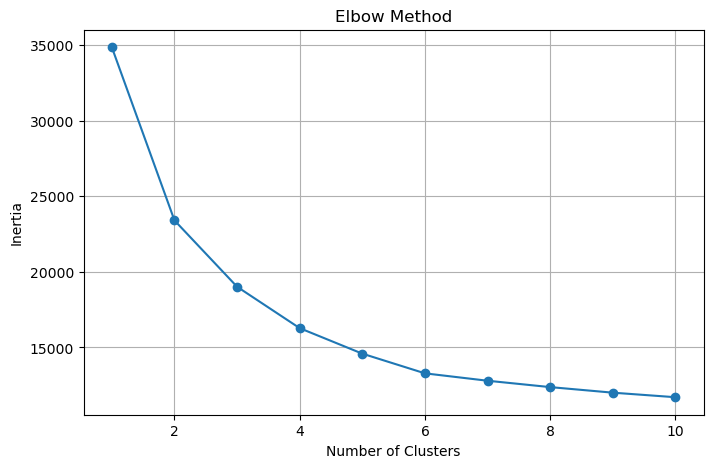

Silhouette Score: 0.243
Cluster
1    1995
0    1788
3    1552
2    1406
Name: count, dtype: int64
           gender  SeniorCitizen  Dependents    tenure  PhoneService  \
Cluster                                                                
0        0.508949       0.076622    0.410515  0.346929      0.767338   
1        0.498246       0.156391    0.215038 -1.117768      0.893734   
2        0.506401       0.259602    0.238976 -0.129802      1.000000   
3        0.500644       0.203608    0.355670  1.256244      0.971005   

         MultipleLines  MonthlyCharges     Churn  InternetService_Fiber optic  \
Cluster                                                                         
0             0.409396       -0.994491  0.076622                     0.450224   
1             0.429574       -0.227621  0.483208                     0.437594   
2             0.404694        0.740894  0.351351                     0.418919   
3             0.443299        0.923691  0.126289                

In [5]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import pandas as pd
import os

# Checking Data Preprocessing Already Executed
if os.path.exists(r"data\Dataset_ATS_v2_backup.csv"):
    cleanedPath = r"data\Dataset_ATS_v2.csv"
    
    df = pd.read_csv(cleanedPath)
    
    print("Cleaned dataset loaded")
    print(df.shape)
    
    # Remove target variable
    X = df.drop(columns=["Churn"])
    
    # Elbow Method
    inertia = []
    
    for k in range(1, 11):
        model = KMeans(
            n_clusters=k,
            random_state=42,
            n_init=10
        )
        model.fit(X)
        inertia.append(model.inertia_)
    
    plt.figure(figsize=(8,5))
    plt.plot(range(1,11), inertia, marker='o')
    plt.xlabel("Number of Clusters")
    plt.ylabel("Inertia")
    plt.title("Elbow Method")
    plt.grid(True)
    plt.show()
    
    # Train final model (example: K=4)
    kmeans = KMeans(
        n_clusters=4,
        random_state=42,
        n_init=10
    )
    
    kmeans.fit(X)
    
    # Assign clusters
    df["Cluster"] = kmeans.labels_
    
    # Evaluate
    score = silhouette_score(X, kmeans.labels_)
    print("Silhouette Score:", round(score, 3))
    
    # Cluster sizes
    print(df["Cluster"].value_counts())
    
    # Cluster summary
    print(df.groupby("Cluster").mean(numeric_only=True))
    
    # Save clustered dataset
    df.to_csv("data/Dataset_ATS_v2_clustered.csv", index=False)
    
    print("Clustering completed successfully.")

else:
    print("Please Run the Data Preprocessing First")